# Important DataFrame & Series Methods — Session 18

In the last two sessions you met the Series and the DataFrame and learned to build, inspect, select, and filter them. This session is the tool drawer: a deliberate, method-by-method tour of the DataFrame functions you will reach for in almost every real analysis. Each method is demonstrated on small toy frames first, so the behaviour is crystal clear, and then on real datasets — movies, IPL matches, and student records — so you can see the method solving an actual problem.

The session follows a natural pipeline. It opens with frequency: which values repeat, and how often — that is value_counts. Then it moves the data around: sorting by values or by index, and re-labelling with set_index and reset_index. Along the way you will compute ranks for leaderboards, rename columns, count unique values, and then enter the world of missing data — detecting it with isnull and notnull, deleting it with dropna, and patching it with fillna. Duplicates get their own pair of tools, drop_duplicates and duplicated, and whole rows or columns can be removed with drop. Custom logic arrives through apply, membership checks through isin, and relationships between numeric columns through corr. The session finishes with quick top-N extraction via nlargest and nsmallest, positional column addition via insert, and safe copying with copy.

Here is the one-line mental map to hold onto: most pandas methods return a NEW object and leave the original untouched — if you want the change to be permanent, pass inplace=True where it is supported. Throughout the session, keep asking two questions of every method: what does it operate on (Series, DataFrame, or both?), and what does it return? Answer those two questions and the entire set of methods becomes predictable.

This session is dense by design. Do not rush — work the code cells in order, predict each output, and let the repetition across toy data and real data build the muscle memory you will carry into grouping and merging next.

### Core ideas
DataFrame is tabular (rows/cols), labeled axes. Series is 1D.

### Why
Facilitates selection, filtering, aggregation, joins, I/O.

### AI relevance
Preprocessing/EDA.


In [1]:
# value_counts
# sort_values
# rank
# sort index
# set index
# rename index -> rename
# reset index
# unique & nunique
# isnull/notnull/hasnans
# dropna
# fillna
# drop_duplicates
# drop
# apply
# isin
# corr
# nlargest -> nsmallest
# insert
# copy

In [2]:
import numpy as np
import pandas as pd

# 1. value_counts — Frequency Analysis

## 1.1 value_counts on Series and DataFrames

The simplest way to explore a categorical column is to count how often each distinct value appears, and value_counts does exactly that.

```python
a = pd.Series([1, 1, 1, 2, 2, 3])
a.value_counts()
```

On a Series, value_counts returns a NEW Series whose index holds the unique values and whose values hold the counts, sorted in descending order by default. The output says 1 appears 3 times, 2 appears twice, and 3 once — the frequency table of the column.

On a DataFrame the behaviour extends to ROWS: `marks.value_counts()` counts how many times each full row combination repeats. In the demo frame of five rows, the row [80, 70, 14] appears twice and every other row once, which is exactly what the output reports.

The usual companions round out the method: `normalize=True` gives proportions instead of raw counts, `ascending=True` flips the sort, `dropna=False` includes missing values in the table, and a `bins=` argument can even bucket a numeric column into a miniature histogram. For a first look at any categorical column, value_counts is the number-one tool.

## 1.2 value_counts in the wild

The notebook then points value_counts at real cricket data:

```python
ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()
```

Read it as a pipeline. First select the rows whose MatchNumber is NOT a pure digit — that keeps exactly the finals, qualifiers, and eliminators, whose names are words. Among those high-pressure games, count the player-of-the-match awards. The output is a frequency table of the heroes of knockout matches: KA Pollard, F du Plessis, and SK Raina leading with three awards each, several bowlers with two, and a long tail of players with one.

Two further cells show value_counts feeding a plot and summing across columns. `ipl['TossDecision'].value_counts().plot(kind='pie')` renders the toss decisions as a pie chart in one line — pandas turns the count table straight into a picture. And the 'matches per team' question is answered by adding two count tables: `ipl['Team2'].value_counts() + ipl['Team1'].value_counts()` counts how often each team appears on either side of a match, and `sort_values(ascending=False)` puts the most-frequent franchise — Mumbai Indians — on top. Counting, plotting, and combining columns: value_counts powers all three.

## 1.3 Deep dive — frequency analysis

The toy example is worth one more pass because it shows the full shape of the result.

```python
a = pd.Series([1, 1, 1, 2, 2, 3])
a.value_counts()
```

value_counts returns a Series: the index is the set of unique input values, and the values are their counts. This is why you can chain a right-hand operation directly — `a.value_counts().plot(kind='bar')` plots each unique value on the x-axis with its count as the bar height, and `.sort_index()` reorders the bars by value rather than by frequency.

The dataframe variant counts identical full rows, which is the SQL-equivalent of a GROUP BY over every column in the frame. In the marks demo, two students scored exactly [80, 70, 14], so that combination earns a count of 2 while the other rows each stand alone.

Remember that value_counts by default EXCLUDES NaN and sorts descending. If a category seems to have vanished from the output, that is the missing-value exclusion, and `dropna=False` will bring it back as an explicit row. This one method—a count of every distinct value, already sorted — is the closest pandas comes to instant statistics for a categorical column, and nearly every 'how many of each' question in data analysis starts with a call to it.

In [3]:
a = pd.Series([1,1,1,2,2,3])
a.value_counts()

1    3
2    2
3    1
Name: count, dtype: int64

In [4]:
# value_counts(series and dataframe)


marks = pd.DataFrame([
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,70,14],
    [80,70,14]
],columns=['iq','marks','package'])

marks

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14
4,80,70,14


In [5]:
marks.value_counts()

iq   marks  package
80   70     14         2
100  80     10         1
90   70     7          1
120  100    14         1
Name: count, dtype: int64

In [6]:
ipl = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/IPL_Matches_2008_2022.csv')
ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()

Player_of_Match
F du Plessis         3
KA Pollard           3
SK Raina             3
JJ Bumrah            2
SR Watson            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
YK Pathan            2
A Kumble             2
HH Pandya            1
JC Buttler           1
RM Patidar           1
DA Miller            1
VR Iyer              1
SP Narine            1
RD Gaikwad           1
TA Boult             1
MP Stoinis           1
KS Williamson        1
RR Pant              1
SA Yadav             1
Rashid Khan          1
AD Russell           1
KH Pandya            1
KV Sharma            1
NM Coulter-Nile      1
Washington Sundar    1
BCJ Cutting          1
DA Warner            1
MC Henriques         1
RG Sharma            1
A Nehra              1
V Sehwag             1
UT Yadav             1
Harbhajan Singh      1
BJ Hodge             1
MEK Hussey           1
MS Bisla             1
MS Dhoni             1
CH Gayle             1
MM Patel             1
DE Bollinger      

In [7]:
# find which player has won most potm -> in finals and qualifiers

<Axes: >

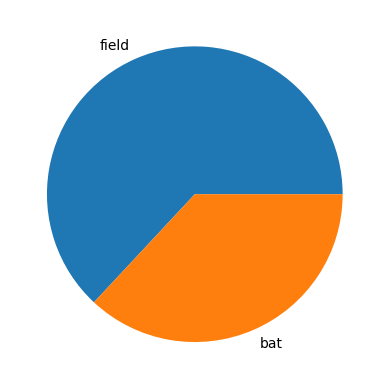

In [8]:
# Toss decision plot
ipl['TossDecision'].value_counts().plot(kind='pie')

In [9]:
# how many matches each team has played
(ipl['Team2'].value_counts() + ipl['Team1'].value_counts()).sort_values(ascending=False)

Team2
Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [10]:
# sort_values(series and dataframe) -> ascending -> na_position -> inplace -> multiple cols

In [11]:
x = pd.Series([12,14,1,56,89])
x

0    12
1    14
2     1
3    56
4    89
dtype: int64

# 2. sort_values — Sorting

## 2.1 Sorting Series and DataFrames

Sorting transforms the familiar into something comparable. `sort_values` orders data by its VALUES, on a Series or on chosen columns of a DataFrame.

```python
x = pd.Series([12, 14, 1, 56, 89])
x.sort_values(ascending=False)
```

The Series demo sorts descending, so 89, 56, 14, 12, 1 fall into order, each keeping its original index label — the output still shows row 4 for 89 and row 0 for 12.

On a DataFrame you name the sort keys:

```python
movies.sort_values('title_x', ascending=False)
movies.sort_values(['year_of_release', 'title_x'], ascending=[True, False])
```

`sort_values('title_x')` reorders the whole movie table by title. With two keys you get a tie-breaker sort: first by year ascending, then within the same year by title descending — like sorting a contacts list by surname and then by first name. The `ascending` parameter accepts either a single boolean or a list matching the column list, and `na_position='first'` (seen with the students frame) forces missing values to the top.

By default sort_values returns a newly sorted copy. Add `inplace=True` and the original object is reordered permanently instead.

## 2.2 Sorting with na_position and inplace

The students example shows both parameters in one call:

```python
students.sort_values('name', na_position='first', ascending=False, inplace=True)
```

The students frame deliberately contains four rows with NaN names. `na_position='first'` pushes those missing-name rows to the top of the result; `ascending=False` then orders the named students from z to a — rupesh before rishabh, then mrityunjay, and so on down to aditya. `inplace=True` makes the new order permanent, which the following cell confirms by printing the rearranged students table.

na_position has only two legal values, 'first' and 'last', and it addresses the classic question: where do missing keys go when sorting? By default they sink to the bottom; with 'first' they rise to the top. This matters whenever a column has gaps — a sort of the full frame would otherwise bury those rows where you least expect them.

The multi-column movie sort demonstrates the second parameter being a list:

```python
movies.sort_values(['year_of_release', 'title_x'], ascending=[True, False])
```

Pandas sorts primarily by year_of_release (ascending), and within every equal year it sorts by title_x (descending), so the newest-released titles appear first and within a year the titles run from z to a. Whether you sort one column or several, the key question is always the same: which column drives the order, and should missing values lead or trail?

In [12]:
x.sort_values(ascending=False)

4    89
3    56
1    14
0    12
2     1
dtype: int64

In [13]:
movies = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/movies.csv')
movies.head(4)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)


In [14]:
movies.sort_values('title_x',ascending=False)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN
756,Zokkomon,tt1605790,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zokkomon,Zokkomon,Zokkomon,0,2011,109,Action|Adventure,4.0,274,After the passing of his parents in an acciden...,An orphan is abused and abandoned believed to...,Betrayal. Friendship. Bravery.,Darsheel Safary|Anupam Kher|Manjari Fadnnis|Ti...,NaN,22 April 2011 (India)
670,Zindagi Tere Naam,tt2164702,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Tere_Naam,Zindagi Tere Naam,Zindagi Tere Naam,0,2012,120,Romance,4.7,27,Mr. Singh an elderly gentleman relates to hi...,Mr. Singh an elderly gentleman relates to hi...,NaN,Mithun Chakraborty|Ranjeeta Kaur|Priyanka Meht...,1 win,16 March 2012 (India)
778,Zindagi Na Milegi Dobara,tt1562872,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Na_Mileg...,Zindagi Na Milegi Dobara,Zindagi Na Milegi Dobara,0,2011,155,Comedy|Drama,8.1,60826,Three friends decide to turn their fantasy vac...,Three friends decide to turn their fantasy vac...,NaN,Hrithik Roshan|Farhan Akhtar|Abhay Deol|Katrin...,30 wins & 22 nominations,15 July 2011 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,1971 (2007 film),tt0983990,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1971_(2007_film),1971,1971,0,2007,160,Action|Drama|War,7.9,1121,Based on true facts the film revolves around ...,Based on true facts the film revolves around ...,Honor the heroes.......,Manoj Bajpayee|Ravi Kishan|Deepak Dobriyal|,1 win,9 March 2007 (India)
723,1920: The Evil Returns,tt2222550,https://upload.wikimedia.org/wikipedia/en/e/e7...,https://en.wikipedia.org/wiki/1920:_The_Evil_R...,1920: Evil Returns,1920: Evil Returns,0,2012,124,Drama|Horror|Romance,4.8,1587,This story revolves around a famous poet who m...,This story revolves around a famous poet who m...,Possession is back,Vicky Ahuja|Tia Bajpai|Irma Jämhammar|Sharad K...,NaN,2 November 2012 (India)
287,1920: London,tt5638500,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_London,1920 London,1920 London,0,2016,120,Horror|Mystery,4.1,1373,Shivangi (Meera Chopra) lives in London with h...,After her husband is possessed by an evil spir...,Fear strikes again,Sharman Joshi|Meera Chopra|Vishal Karwal|Suren...,NaN,6 May 2016 (USA)
1021,1920 (film),tt1301698,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_(film),1920,1920,0,2008,138,Horror|Mystery|Romance,6.4,2588,A devotee of Bhagwan Shri Hanuman Arjun Singh...,After forsaking his family and religion a hus...,A Love Made in Heaven...A Revenge Born in Hell...,Rajniesh Duggall|Adah Sharma|Anjori Alagh|Raj ...,NaN,12 September 2008 (India)


In [15]:
students = pd.DataFrame(
    {
        'name':['nitish','ankit','rupesh',np.nan,'mrityunjay',np.nan,'rishabh',np.nan,'aditya',np.nan],
        'college':['bit','iit','vit',np.nan,np.nan,'vlsi','ssit',np.nan,np.nan,'git'],
        'branch':['eee','it','cse',np.nan,'me','ce','civ','cse','bio',np.nan],
        'cgpa':[6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
        'package':[4,5,6,np.nan,6,7,8,9,np.nan,np.nan]

    }
)

students

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [16]:
students.sort_values('name',na_position='first',ascending=False,inplace=True)

In [17]:
students

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [18]:
movies.sort_values(['year_of_release','title_x'],ascending=[True,False])

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India)
1620,Yeh Raaste Hain Pyaar Ke,tt0292740,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Raaste_Hain_...,Yeh Raaste Hain Pyaar Ke,Yeh Raaste Hain Pyaar Ke,0,2001,149,Drama|Romance,4.0,607,Two con artistes and car thieves Vicky (Ajay ...,Two con artistes and car thieves Vicky (Ajay ...,Love is a journey... not a destination,Ajay Devgn|Madhuri Dixit|Preity Zinta|Vikram G...,NaN,10 August 2001 (India)
1573,Yaadein (2001 film),tt0248617,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yaadein_(2001_film),Yaadein...,Yaadein...,0,2001,171,Drama|Musical|Romance,4.4,3034,Raj Singh Puri is best friends with L.K. Malho...,Raj Singh Puri is best friends with L.K. Malho...,memories to cherish...,Jackie Shroff|Hrithik Roshan|Kareena Kapoor|Am...,1 nomination,27 June 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA)
46,Arjun Patiala,tt7881524,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Arjun_Patiala,Arjun Patiala,Arjun Patiala,0,2019,107,Action|Comedy,4.1,676,Arjun Patiala(Diljit Dosanjh)has recently been...,This spoof comedy narrates the story of a cop ...,NaN,Diljit Dosanjh|Kriti Sanon|Varun Sharma|Ronit ...,NaN,26 July 2019 (USA)
10,Amavas,tt8396186,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Amavas,Amavas,Amavas,0,2019,134,Horror|Thriller,2.8,235,Far away from the bustle of the city a young ...,The lives of a couple turn into a nightmare a...,NaN,Ali Asgar|Vivan Bhatena|Nargis Fakhri|Sachiin ...,NaN,8 February 2019 (India)
26,Albert Pinto Ko Gussa Kyun Aata Hai?,tt4355838,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Albert_Pinto_Ko_...,Albert Pinto Ko Gussa Kyun Aata Hai?,Albert Pinto Ko Gussa Kyun Aata Hai?,0,2019,100,Drama,4.8,56,Albert leaves his house one morning without te...,Albert Pinto goes missing one day and his girl...,NaN,Manav Kaul|Nandita Das|,NaN,12 April 2019 (India)


In [19]:
# rank(series)
batsman = pd.read_csv('D:/GENAI/AI-Engineering-Foundations/01_Python/07_Pandas/Datasets/batsman_runs_ipl.csv')
batsman.head()

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25


# 3. rank — Leaderboards

## 3.1 Assigning ranks

Sorting reorders rows; ranking attaches position numbers. The rank method turns values into standings.

```python
batsman = pd.read_csv('batsman_runs_ipl.csv')
batsman['batting_rank'] = batsman['batsman_run'].rank(ascending=False)
```

The batsman data holds each IPL batter's career runs. `batsman['batsman_run'].rank(ascending=False)` asks pandas to rank the runs column so that the HIGHEST run total receives rank 1 — the parameter name reads 'give rank 1 to the largest value'. The result is stored in a brand-new column, batting_rank.

When the sorted frame is printed, the rank column runs 1, 2, 3, 4, 5 down the page: V Kohli at 6634 runs sits at rank 1, S Dhawan at 6244 at rank 2, DA Warner at 5883 at rank 3, RG Sharma at 5881 at rank 4, SK Raina at 5536 at rank 5. A leaderboard in one expression.

Ties deserve care: by default rank uses the method='average', so tied values share the average of their positions — a pair tied for positions 6 and 7 would both receive 6.5. The `method` parameter offers 'min', 'max', 'first', and 'dense' for other tie policies, and `pct=True` converts ranks into percentages. When two batsmen share a total, decide the tie policy before you read anything else into the ranking column.

In [20]:
batsman['batting_rank'] = batsman['batsman_run'].rank(ascending=False)
batsman.sort_values('batting_rank')

,batter,batsman_run,batting_rank
569,V Kohli,6634,1.0
462,S Dhawan,6244,2.0
130,DA Warner,5883,3.0
430,RG Sharma,5881,4.0
493,SK Raina,5536,5.0
...,...,...,...
570,V Pratap Singh,0,594.0
63,Abdur Razzak,0,594.0
562,U Kaul,0,594.0
65,Akash Deep,0,594.0


In [21]:
# sort_index(series and dataframe)

In [22]:
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks)
marks_series

maths       67
english     57
science     89
hindi      100
dtype: int64

# 4. Managing the Index

## 4.1 sort_index, set_index, reset_index

The index is the identity of a DataFrame, and three methods control how it is ordered, promoted, and demoted.

```python
marks_series.sort_index(ascending=False)
movies.sort_index(ascending=False)
```

`sort_index` orders rows by their LABELS instead of their values. On the marks Series the labels are the subject names, so sorting descending puts science, maths, hindi, english in order. On the movies DataFrame the index is the 0-1628 RangeIndex, so sorting it descending effectively reverses the file's row order.

```python
batsman.set_index('batter', inplace=True)   # column -> index
batsman.reset_index(inplace=True)          # index -> column
batsman.reset_index().set_index('batting_rank')
```

`set_index('batter')` SWAPS a column into the index — the batter names become row labels, so the frame can be looked up by player. `reset_index` undoes it, turning the current index back into an ordinary column and restoring the 0-to-n RangeIndex. The combined one-liner `batsman.reset_index().set_index('batting_rank')` performs both at once: flatten the current multi-column index, then promote batting_rank to be the new row label. Two methods in one breath give you complete control over which column names the rows of your table.

## 4.2 set_index and reset_index in action

The notebooks cells walk the index lifecycle in detail, and tracking the printing at each step is the correct way to understand it.

After `batsman.set_index('batter', inplace=True)`, the output stops showing a 0-to-n range on the left and instead shows batter names — A Ashish Reddy, A Badoni, A Chandila — with batsman_run and batting_rank to their right. The once-plain index has become a meaningful key.

`batsman.reset_index()` (with inplace) then runs in reverse: the batter names move back into a regular column and the range index returns, exactly as the first output shows. The following print of `batsman` re-shows the frame still with 'batter' as index because reset_index came after; read each printed table in the position where pandas printed it, and the sequence tells the full story.

The penultimate trick, `marks_series.reset_index()`, shows the Series-to-DataFrame conversion: a Series, when reset, produces a two-column DataFrame whose first column is named index and holds the old labels (maths, english, science, hindi), and whose second column holds the values. Finally, `movies.set_index('title_x', inplace=True)` from the rename section converts the movie title column into row labels so that each row can later be addressed by its title. The rhythm — promote with set_index, demote with reset_index — is one of the most common data-hygiene cycles in pandas.

In [23]:
marks_series.sort_index(ascending=False)

science     89
maths       67
hindi      100
english     57
dtype: int64

In [24]:
movies.sort_index(ascending=False)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1628,Humsafar,tt2403201,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Humsafar,Humsafar,Humsafar,0,2011,35,Drama|Romance,9.0,2968,Sara and Ashar are childhood friends who share...,Ashar and Khirad are forced to get married due...,NaN,Fawad Khan|,NaN,TV Series (2011–2012)
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [25]:
# set_index(dataframe) -> inplace
batsman.set_index('batter',inplace=True)

In [26]:
batsman

,batsman_run,batting_rank
batter,,
A Ashish Reddy,280,166.5
A Badoni,161,226.0
A Chandila,4,535.0
A Chopra,53,329.0
A Choudhary,25,402.5
...,...,...
Yash Dayal,0,594.0
Yashpal Singh,47,343.0
Younis Khan,3,547.5


In [27]:
# reset_index(series + dataframe) -> drop parameter
batsman.reset_index(inplace=True)

In [28]:
batsman

,batter,batsman_run,batting_rank
0,A Ashish Reddy,280,166.5
1,A Badoni,161,226.0
2,A Chandila,4,535.0
3,A Chopra,53,329.0
4,A Choudhary,25,402.5
...,...,...,...
600,Yash Dayal,0,594.0
601,Yashpal Singh,47,343.0
602,Younis Khan,3,547.5
603,Yuvraj Singh,2754,27.0


In [29]:
# how to replace existing index without loosing
batsman.reset_index().set_index('batting_rank')

,index,batter,batsman_run
batting_rank,,,
166.5,0,A Ashish Reddy,280
226.0,1,A Badoni,161
535.0,2,A Chandila,4
329.0,3,A Chopra,53
402.5,4,A Choudhary,25
...,...,...,...
594.0,600,Yash Dayal,0
343.0,601,Yashpal Singh,47
547.5,602,Younis Khan,3


In [30]:
# series to dataframe using reset_index
marks_series.reset_index()

,index,0
0,maths,67
1,english,57
2,science,89
3,hindi,100


In [31]:
# rename(dataframe) -> index

In [32]:
movies.set_index('title_x',inplace=True)

# 5. Renaming and Unique Values

## 5.1 rename, unique, nunique

Three quick methods modernise column names and summarise the distinct values inside them.

```python
movies.rename(columns={'imdb_id': 'imdb', 'poster_path': 'link'}, inplace=True)
movies.rename(index={'Uri: The Surgical Strike': 'Uri', 'Battalion 609': 'Battalion'})
```

`rename` takes a dictionary of old-name to new-name pairs. With `columns=`, the keys are column names; with `index=`, the keys are row labels. The first call permanently shortens two header names to imdb and link; the second (without inplace) returns a renamed copy where two long movie titles become Uri and Battalion, leaving the original untouched. Rename is documentation you can run.

```python
temp = pd.Series([1, 1, 2, 2, 3, 3, 4, 4, 5, 5, np.nan, np.nan])
temp.unique()
temp.nunique()
```

`unique()` returns the array of distinct values in order of first appearance — for this Series, six entries including one NaN. `nunique()` returns the COUNT of distinct values, and by default it SKIPS NaN — hence 5, one less than len(unique()). `nunique(dropna=False)` would count the missing value too. On a DataFrame, `nunique` returns per-column counts: how many distinct seasons are in ipl? The cells report 15 — fifteen IPL seasons in the matches file.

In [33]:
movies.rename(columns={'imdb_id':'imdb','poster_path':'link'},inplace=True)

In [34]:
movies.rename(index={'Uri: The Surgical Strike':'Uri','Battalion 609':'Battalion'})

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN


In [35]:
# unique(series)
temp = pd.Series([1,1,2,2,3,3,4,4,5,5,np.nan,np.nan])
print(temp)

0     1.0
1     1.0
2     2.0
3     2.0
4     3.0
5     3.0
6     4.0
7     4.0
8     5.0
9     5.0
10    NaN
11    NaN
dtype: float64


In [36]:
len(temp.unique())

6

In [37]:
temp.nunique()

5

In [38]:
len(ipl['Season'].unique())

15

In [39]:
# nunique(series + dataframe) -> does not count nan -> dropna parameter
ipl['Season'].nunique()

15

# 6. Missing Value Detection

## 6.1 isnull, notnull, hasnans

Before deciding what to DO with missing values, you have to find them. Three helpers make the detection explicit.

```python
students['name'][students['name'].isnull()]
students['name'][students['name'].notnull()]
```

`isnull()` returns a boolean mask — True exactly where the value is missing. Wrapping it in square brackets filters the Series to just the missing rows; the output shows the four NaN-name students. `notnull()` is the logical opposite, and its mask keeps precisely the students who HAVE a name.

```python
students['name'].hasnans
students.isnull()
students.notnull()
```

`hasnans` is a single-boolean question: does this Series contain any NaN at all? Here it answers True. On a DataFrame, `isnull()` and `notnull()` return an entire grid of True/False — every cell gets a verdict — which is the full data-quality portrait of the table at once.

The idioms compose into reports: `df.isnull().sum()` counts the missing values per column in one line, and `df[df['col'].isnull()]` extracts the offending rows for a closer look. isna is a full alias of isnull — both spell the same question. These tools are the gatekeepers of every cleaning pipeline: nothing gets dropped or filled until you have seen the holes clearly.

In [40]:
# isnull(series + dataframe)
students['name'][students['name'].isnull()]

3    NaN
5    NaN
7    NaN
9    NaN
Name: name, dtype: str

In [41]:
# notnull(series + dataframe)
students['name'][students['name'].notnull()]

2        rupesh
6       rishabh
0        nitish
4    mrityunjay
1         ankit
8        aditya
Name: name, dtype: str

In [42]:
# hasnans(series)
students['name'].hasnans

True

In [43]:
students

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [44]:
students.isnull()

,name,college,branch,cgpa,package
3,True,True,True,True,True
5,True,False,False,False,False
7,True,True,False,False,False
9,True,False,True,True,True
2,False,False,False,False,False
6,False,False,False,False,False
0,False,False,False,False,False
4,False,True,False,False,False
1,False,False,False,False,False
8,False,True,False,False,True


In [45]:
students.notnull()

,name,college,branch,cgpa,package
3,False,False,False,False,False
5,False,True,True,True,True
7,False,False,True,True,True
9,False,True,False,False,False
2,True,True,True,True,True
6,True,True,True,True,True
0,True,True,True,True,True
4,True,False,True,True,True
1,True,True,True,True,True
8,True,False,True,True,False


# 7. Handling Missing Values

## 7.1 dropna and fillna

Once the holes are mapped, two strategies resolve them: delete the bad rows or patch the bad values.

```python
students.dropna(how='any')
students.dropna(how='all')
students.dropna(subset=['name'])
students.dropna(subset=['name', 'college'])
```

`dropna` removes rows containing missing values. The `how` parameter is the policeman: `how='any'` drops a row if ANY value inside it is NaN (the strictest, largest effect), while `how='all'` drops a row only if ALL of its values are NaN (here, the one fully-empty student row). The `subset` parameter narrows the inspection to specific columns — `subset=['name']` drops a row only when the name is missing, and `subset=['name', 'college']` drops when EITHER of those two is missing. With inplace=True the deletions are permanent.

```python
students['name'].fillna('unknown')
students['package'].fillna(students['package'].mean())
students['name'].fillna(method='bfill')
```

`fillna` replaces gaps instead of deleting them. A constant ('unknown') stamps a fixed label; a statistic (the package mean, 6.428571) fills numeric gaps with a representative value; and `method='bfill'` copies the NEXT valid value backwards into each hole (forward-fill with 'ffill' reverses the direction). Choose drop when the holes are few and unimportant, choose fill when the column matters — and let the data's story decide which fill value is honest.

In [46]:
# dropna(series + dataframe) -> how parameter -> works like or
students['name'].dropna()

2        rupesh
6       rishabh
0        nitish
4    mrityunjay
1         ankit
8        aditya
Name: name, dtype: str

In [47]:
students

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [48]:
students.dropna(how='any')

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0


In [49]:
students.dropna(how='all')

,name,college,branch,cgpa,package
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [50]:
students.dropna(subset=['name'])

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [51]:
students.dropna(subset=['name','college'])

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0


In [52]:
students.dropna(inplace=True)

In [53]:
# fillna(series + dataframe)
students['name'].fillna('unknown')

2     rupesh
6    rishabh
0     nitish
1      ankit
Name: name, dtype: str

In [54]:
students

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0


In [55]:
students['package'].fillna(students['package'].mean())

2    6.0
6    8.0
0    4.0
1    5.0
Name: package, dtype: float64

In [56]:
students['name'].bfill()

2     rupesh
6    rishabh
0     nitish
1      ankit
Name: name, dtype: str

In [57]:
# drop_duplicates(series + dataframe) -> works like and -> duplicated()

# 8. Duplicates

## 8.1 drop_duplicates and duplicated

Duplicate detection mirrors the missing-value pairing: one method reports, one method removes.

```python
temp = pd.Series([1, 1, 1, 2, 3, 3, 4, 4])
temp.drop_duplicates()
```

On a Series, drop_duplicates keeps the first occurrence of each value and removes later repeats, returning 1, 2, 3, 4 in the positions of their first appearances.

```python
marks.drop_duplicates(keep='last')
```

On a DataFrame, drop_duplicates removes duplicate ROWS. `keep='last'` keeps the final occurrence of each repeated row — in the marks frame, the second [80, 70, 14] row survives and the first is dropped. `keep='first'` (the default) and `keep=False` (remove every copy) complete the trio, and a `subset=` argument lets you judge duplicates on specific columns only.

The detection partner is `duplicated()`: it returns a boolean Series marking every repeat, and `.sum()` tallies them. The real-data example — `ipl['all_players'].apply(did_kohli_play)` combined with a City filter — shows the full flow: a user-defined function checks whether Kohli played, then drop_duplicates(subset=['City', 'did_kohli_play'], keep='first') keeps the earliest Delhi match where he appeared. Duplicates, detected and removed, are a staple of every cleaning job.

In [58]:
temp = pd.Series([1,1,1,2,3,3,4,4])
temp.drop_duplicates()

0    1
3    2
4    3
6    4
dtype: int64

In [59]:
# find the last match played by virat kohli in Delhi
ipl['all_players'] = ipl['Team1Players'] + ipl['Team2Players']
ipl.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all_players
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ..."
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,...,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ..."
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,...,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ..."
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,...,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ..."
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,...,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ..."


In [60]:
def did_kohli_play(players_list):
  return 'V Kohli' in players_list

In [61]:
ipl['did_kohli_play'] = ipl['all_players'].apply(did_kohli_play)
ipl[(ipl['City'] == 'Delhi') & (ipl['did_kohli_play'] == True)].drop_duplicates(subset=['City','did_kohli_play'],keep='first')

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all_players,did_kohli_play
208,1178421,Delhi,2019-04-28,2019,46,Delhi Capitals,Royal Challengers Bangalore,Arun Jaitley Stadium,Delhi Capitals,bat,...,Runs,16.0,NaN,S Dhawan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...","['PA Patel', 'V Kohli', 'AB de Villiers', 'S D...",BNJ Oxenford,KN Ananthapadmanabhan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...",True


In [62]:
students.drop_duplicates()

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0


In [63]:
# drop(series + dataframe)
temp = pd.Series([10,2,3,16,45,78,10])
temp

0    10
1     2
2     3
3    16
4    45
5    78
6    10
dtype: int64

# 9. drop — Removing Rows and Columns

## 9.1 drop rows, drop columns

The precise counterpart to selecting is removing, served by the drop method.

```python
temp.drop(index=[0, 6])
```

On a Series, `drop(index=[0, 6])` removes the rows at labels 0 and 6. The demo temp Series holds [10, 2, 3, 16, 45, 78, 10], and dropping positions 0 and 6 leaves [2, 3, 16, 45, 78] — both copies of the 10 vanish, because those two positions hold the value 10.

```python
students.drop(columns=['branch', 'cgpa'], inplace=True)
students.set_index('name').drop(index=['nitish', 'aditya'])
```

On a DataFrame, `drop(columns=['branch', 'cgpa'])` removes two columns at once, and with inplace=True the trimmed table becomes permanent — the later print shows only name, college, and package. Drop rows by label with `index=`; after `set_index('name')`, the drop is by student names, so `drop(index=['nitish', 'aditya'])` removes exactly those players and leaves ankit, rupesh, and the rest. The axis=1 shorthand `df.drop('col', axis=1)` means the same as columns=. Selecting keeps the data you want; dropping deletes what you do not — two senses of the same thought, and drop completes the grammar.

In [64]:
temp.drop(index=[0,6])

1     2
2     3
3    16
4    45
5    78
dtype: int64

In [65]:
students

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0


In [66]:
students.drop(columns=['branch','cgpa'],inplace=True)
students

,name,college,package
2,rupesh,vit,6.0
6,rishabh,ssit,8.0
0,nitish,bit,4.0
1,ankit,iit,5.0


In [69]:
students.set_index('name').drop(index=['rishabh','rupesh'])

,college,package
name,,
nitish,bit,4.0
ankit,iit,5.0


In [70]:
# apply(series + dataframe)
temp = pd.Series([10,20,30,40,50])

temp

0    10
1    20
2    30
3    40
4    50
dtype: int64

In [71]:
def sigmoid(value):
  return 1/1+np.exp(-value)

# 10. apply — Custom Functions

## 10.1 apply on Series and DataFrames

Built-in methods cover standard maths, but custom logic needs a door: apply runs YOUR function over values, rows, or columns.

```python
temp = pd.Series([10, 20, 30, 40, 50])
def sigmoid(value):
    return 1/1+np.exp(-value)
temp.apply(sigmoid)
```

On a Series, `apply(fn)` feeds every VALUE to the function and collects the results as a new Series. The sigmoid demo maps each number through the (admittedly parenthesised-questionably) sigmoid expression, and the output is a new Series small but transformed — the point being that a Python def can be plugged straight in.

The DataFrame form adds an axis:

```python
points_df = pd.DataFrame({...})  # columns of coordinate tuples
points_df['distance'] = points_df.apply(euclidean, axis=1)
```

The euclidean function reads two coordinate points from a ROW, computes the distance by the usual formula, and returns a single number. `apply(euclidean, axis=1)` hands pandas every row one at a time, and the returned numbers become the new distance column. axis=1 = row-wise; axis=0 = column-wise.

apply is the escape hatch of pandas: when no built-in fits, write a function and apply it. Its price is speed — a Python function call per element is slower than native vectorised ops — so use it for the genuinely custom cases and prefer named pandas methods everywhere else.

In [72]:
temp.apply(sigmoid)

0    1.000045
1    1.000000
2    1.000000
3    1.000000
4    1.000000
dtype: float64

In [73]:
points_df = pd.DataFrame(
    {
        '1st point':[(3,4),(-6,5),(0,0),(-10,1),(4,5)],
        '2nd point':[(-3,4),(0,0),(2,2),(10,10),(1,1)]
    }
)

points_df

,1st point,2nd point
0,"(3, 4)","(-3, 4)"
1,"(-6, 5)","(0, 0)"
2,"(0, 0)","(2, 2)"
3,"(-10, 1)","(10, 10)"
4,"(4, 5)","(1, 1)"


In [74]:
def euclidean(row):
  pt_A = row['1st point']
  pt_B = row['2nd point']

  return ((pt_A[0] - pt_B[0])**2 + (pt_A[1] - pt_B[1])**2)**0.5

In [75]:
points_df['distance'] = points_df.apply(euclidean,axis=1)
points_df

,1st point,2nd point,distance
0,"(3, 4)","(-3, 4)",6.000000
1,"(-6, 5)","(0, 0)",7.810250
2,"(0, 0)","(2, 2)",2.828427
3,"(-10, 1)","(10, 10)",21.931712
4,"(4, 5)","(1, 1)",5.000000


# 11. isin — Membership

## 11.1 isin filters by a list

isin answers one question for the whole column at once: is this value one of the values I care about?

```python
df[df['col'].isin([...])]
```

The pattern is boolean masking with a membership test instead of a comparison. `df['col'].isin(a_list)` returns True wherever the cell's value appears in the list, and the surrounding brackets keep exactly those rows. It is pandas' version of SQL's IN clause.

On a Series the same call filters values directly: a batting-runs Series filtered by `vk.isin([49, 99])` keeps only the scores 49 and 99 — the near-misses. Written as an OR chain, the same filter needs `(vk == 49) | (vk == 99)`, which gets unwieldy the longer the list grows. isin swaps the whole chain for one word.

isin is also composable: combine its mask with other conditions using &, |, and ~, and wrap with parentheses. `courses[~courses['course_id'].isin(regs['course_id'])]` — the tilde inverts the mask — finds every course with NO registration, a pattern that returns in the merging session as the anti-join. Whatever the whitelist — ids, names, categories — isin turns 'values belonging to a fixed set' into a clean filter.

In [76]:
# isin(series)

# 12. corr — Correlation

## 12.1 corr measures relationships

When two numeric columns move together, correlation quantifies it. `df.corr()` computes the pairwise Pearson correlation matrix of every numeric column against every other.

The resulting table is symmetric: the diagonal is always 1.0 (each column correlates perfectly with itself), and the off-diagonal cells run from -1 to +1. A value near +1 means 'as one rises, the other rises' — strong positive relationship. A value near -1 means 'as one rises, the other falls' — strong negative relationship. A value near 0 means the two wiggle independently.

Correlation is the measuring tape of feature selection. In a dataset full of candidate features, the cells that approach 1 or -1 flag redundant pairs you can collapse; the cells near 0 flag independent information worth keeping. It is also the first warning system for mistakes: an unexpectedly perfect ±1 between two columns usually means one is derived from the other.

The related cells in this notebook run corr on the available numeric columns and leave the result printed as the report; a heatmap visualisation is the usual follow-up and arrives in later plotting sessions. For now, remember the three anchor values — 1, -1, 0 — and the promise of corr: it tells you, in one table, which columns of your data are really saying the same thing.

In [77]:
# corr

# 13. nlargest and nsmallest

## 13.1 Top and bottom N

Sorting then slicing to find the top few is so common that pandas packages it as two dedicated methods.

```python
df.nlargest(n, 'col')
df.nsmallest(n, 'col')
```

On a DataFrame, `nlargest(5, 'col')` returns the five rows with the largest values of column col, pre-sorted in descending order; `nsmallest(5, 'col')` returns the five smallest in ascending order. Each is exactly `df.sort_values('col', ascending=False).head(5)` — but specialised, so pandas can use faster partial-sorting paths.

On a Series the same methods take just a count: `series.nlargest(3)` returns the three largest values. Several columns may be passed to DataFrame.nlargest for tie-breaking, and NaN rows are excluded by default.

Use them for the classic reporting questions: who scored the most? Which courses cost the most? What are the top five player-of-the-match totals? nlargest gives the winners' podium in one line, and nsmallest answers the mirror-image question about the smallest values. Wherever a question phrases itself as 'top N' or 'bottom N', these two methods are the direct translation.

In [78]:
# nlargest and nsmallest(series and dataframe)

# 14. insert — Column Position

## 14.1 Insert a column anywhere

A normal assignment `df['col'] = values` always adds a column at the END of the frame. When the position matters, insert takes over.

```python
df.insert(loc, column, value)
```

The first argument, loc, is the integer position where the new column should land — 0 places it at the front, 3 places it fourth, and so on. The second argument names the column, and the third supplies its values as a Series, list, or scalar, as long as its length matches the frame.

Unlike the assignment syntax, insert always modifies the DataFrame in place and returns None; there is no inplace parameter because there is no copy-based alternative. It also protects you by default: attempting to insert a column name that already exists raises a ValueError unless you pass allow_duplicates=True.

Positional column placement is the tool of tidy-data construction: build a base frame with df['col'] = values and then slot an identifier or a computed field into the front with insert(0, 'id', ...) so the output's column order matches a required report format. Every other column keeps its position, and the new one sits exactly where you asked for it — something the append-at-the-end behaviour of assignment cannot do.

In [79]:
# insert(dataframe)


# 15. copy — Safe Snapshots

## 15.1 copy before you modify

Everything in this session can mutate data, and the cleanest insurance policy against accidental edits is copy.

```python
subset = df.copy()
```

`df.copy()` returns a new DataFrame whose rows and columns are independent of the original. Any edit you make to subset — adding a column, filling NaN, dropping rows — leaves the source frame completely untouched. Without copy, a selection like `subset = df[['a', 'b']]` is only a VIEW onto the same underlying memory, and writes into it can leak back into df, usually accompanied by the notorious SettingWithCopyWarning.

The pattern to internalise:

```python
df_clean = df.copy()       # snapshot for the pipeline
df_clean['x'] = ...        # experiment freely
```

folds into one place: whenever you are about to try something on a DataFrame — especially anything that writes — take a copy first. The identity check `df.copy() is df` returns False, confirming you hold a genuinely different object.

Copy also keeps pipelines stable: one master DataFrame, many copies processed in parallel without interference. The price of a copy is memory; the price of NOT copying can be hours of debugging a silently corrupted dataset. In this session, where dropna, fillna, drop, and insert all reshape frames, a working copy is the safest test bed of all.

In [80]:
# copy(series + dataframe)

## Summary

This session opened your DataFrame toolkit method by method. value_counts built instant frequency tables, sort_values and sort_index rearranged rows, rank produced leaderboards, and set_index, reset_index, and rename managed the labels. unique and nunique summarised distinct values, while isnull, notnull, and hasnans pinpointed missing data — removed with dropna and patched with fillna, and duplicates handled by distinct and drop_duplicates.

drop removed unwanted rows and columns, apply ran custom functions element-wise or row-wise, isin filtered against a whitelist, and corr measured the relationship between numeric columns. nlargest and nsmallest extracted the top and bottom performers, insert placed a column at any position, and copy guaranteed safe, independent snapshots. The through-line to remember: most methods return new objects and leave originals untouched; pass inplace where permanence is wanted. With this toolbox on hand, you are ready to split data into groups and recombine it — the GroupBy session is next.